In [1]:
# imports
import os, glob, math
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
plt.rcParams['figure.figsize'] = (12,5)
print("TF", tf.__version__)


TF 2.20.0


In [3]:
# Data is in Drive, mount it.
from google.colab import drive
drive.mount('/content/drive')

# Set base folder where your dataset is.
BASE_DIR = '/content/drive/MyDrive/major_data'
os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/major_data


In [4]:
# Use the cleaned folder path
csv_files = glob.glob("/content/drive/MyDrive/major_data/cleaned/*.csv")
print("CSV files found:", csv_files)

processed_data = {}

for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)

    print(f"{company_name} raw shape: {df.shape}")  # Check if file has rows/columns

    # Only keep if df is not empty
    if df.shape[0] > 0:
        processed_data[company_name] = df

print("Companies loaded:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [5]:
# Paths
cleaned_folder = "/content/drive/MyDrive/major_data/cleaned"
csv_files = glob.glob(os.path.join(cleaned_folder, "*.csv"))
print("CSV files found:", csv_files)

# Create output folder
output_folder = "/content/drive/MyDrive/major_data/processed_with_features"
os.makedirs(output_folder, exist_ok=True)

# Processed data dictionary
processed_data = {}

# Loop through CSVs
for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    print(f"{company_name} raw shape: {df.shape}")

    # Standardize column names
    df.columns = df.columns.str.strip().str.capitalize()

    # Rename inconsistent columns if needed
    rename_dict = {'Date ': 'Date', 'Close': 'Close', 'Volume': 'Volume'}
    df.rename(columns=rename_dict, inplace=True)

    # Keep only necessary columns
    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[[col for col in df.columns if col in required_cols]]

    # Convert numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Handle missing data
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

    # Convert Date to datetime & sort
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"{company_name} rows after numeric conversion: {df.shape[0]}")

    # Skip if not enough rows
    if df.shape[0] < 5:  # can adjust threshold based on your feature window
        print(f" Skipping {company_name}, not enough rows")
        continue


    # Feature creation for LSTM
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Drop first row which has NaN from pct_change
    df.dropna(inplace=True)

    # Save processed data
    processed_data[company_name] = df
    print(f" Features created for {company_name}: {df.shape}")

    output_file_path = os.path.join(output_folder, f"{company_name}_features.csv")
    df.to_csv(output_file_path, index=False)
    print(f"Saved processed file with features: {output_file_path}")

# Summary
print("Companies ready:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [ ]:
#  To improve prediction accuracy lag features added (LSTM MODEL 2 starts)

In [6]:
pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 66.3 MB/s eta 0:00:00


In [7]:
import talib

for company, df in processed_data.items():
    df = df.copy()

    # Existing features
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Lag features (previous 1-3 days close)
    for lag in range(1, 4):
        df[f'Close_lag{lag}'] = df['Close'].shift(lag)

    # Rolling features
    df['MA_5'] = df['Close'].rolling(5).mean()
    df['MA_10'] = df['Close'].rolling(10).mean()
    df['STD_5'] = df['Close'].rolling(5).std()

    # Technical indicators using TA-Lib
    df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])

    df.dropna(inplace=True)
    processed_data[company] = df
    print(f"{company} features updated: {df.shape}")

Adani Enterprises Ltd features updated: (2726, 20)
Adani ports and special Economic features updated: (2726, 20)
Bajaj Finance Ltd features updated: (2726, 20)
Axis Bank Ltd features updated: (2730, 20)
Bajaj Finserv Ltd features updated: (2726, 20)
Bharat Electronics Ltd features updated: (1109, 20)
Bharti Airtel Ltd features updated: (2726, 20)
Eternal Ltd features updated: (2726, 20)
HCL Technologies Ltd features updated: (2721, 20)
HDFC Bank Ltd features updated: (2726, 20)
Hindustan Unilever Ltd features updated: (2726, 20)
ICICI Bank Ltd features updated: (2726, 20)
ITC Ltd features updated: (2726, 20)
Infosys Ltd features updated: (2726, 20)
JSW Steel Ltd features updated: (2726, 20)
Larsen and Toubro Ltd features updated: (2726, 20)
Kotak Mahindra Bank Ltd features updated: (2721, 20)
Mahindra and Mahindra Ltd features updated: (2726, 20)
Maruti Suzuki India Ltd features updated: (2726, 20)
NTPC Ltd features updated: (2726, 20)
Oil and Natural Gas Corporation Ltd features updat

In [8]:
from sklearn.preprocessing import MinMaxScaler

timesteps = 10
all_lstm_models = {}
feature_columns = [col for col in processed_data['Reliance Industries Ltd'].columns if col != 'Date']

for company, df in processed_data.items():
    n = len(df)
    train_size = int(n*0.7)
    val_size = int(n*0.15)

    train_df = df.iloc[:train_size]
    val_df   = df.iloc[train_size:train_size+val_size]
    test_df  = df.iloc[train_size+val_size:]

    # Feature scaling (fit on train only)
    feature_scaler = MinMaxScaler()
    X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])
    X_val_scaled   = feature_scaler.transform(val_df[feature_columns])
    X_test_scaled  = feature_scaler.transform(test_df[feature_columns])

    # Target scaling
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(train_df[['Close']])
    y_val_scaled   = target_scaler.transform(val_df[['Close']])
    y_test_scaled  = target_scaler.transform(test_df[['Close']])

    # Sequence creation
    def create_sequences(X, y, timesteps):
        X_seq, y_seq = [], []
        for i in range(timesteps, len(X)):
            X_seq.append(X[i-timesteps:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)

    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_val, y_val     = create_sequences(X_val_scaled, y_val_scaled, timesteps)
    X_test, y_test   = create_sequences(X_test_scaled, y_test_scaled, timesteps)

    all_lstm_models[company] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'timesteps': timesteps,
        'feature_columns': feature_columns,
        'type' : 'lstm_model2'

    }

    print(f"{company}: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")


Adani Enterprises Ltd: Train=1898, Val=398, Test=400
Adani ports and special Economic: Train=1898, Val=398, Test=400
Bajaj Finance Ltd: Train=1898, Val=398, Test=400
Axis Bank Ltd: Train=1900, Val=399, Test=401
Bajaj Finserv Ltd: Train=1898, Val=398, Test=400
Bharat Electronics Ltd: Train=766, Val=156, Test=157
Bharti Airtel Ltd: Train=1898, Val=398, Test=400
Eternal Ltd: Train=1898, Val=398, Test=400
HCL Technologies Ltd: Train=1894, Val=398, Test=399
HDFC Bank Ltd: Train=1898, Val=398, Test=400
Hindustan Unilever Ltd: Train=1898, Val=398, Test=400
ICICI Bank Ltd: Train=1898, Val=398, Test=400
ITC Ltd: Train=1898, Val=398, Test=400
Infosys Ltd: Train=1898, Val=398, Test=400
JSW Steel Ltd: Train=1898, Val=398, Test=400
Larsen and Toubro Ltd: Train=1898, Val=398, Test=400
Kotak Mahindra Bank Ltd: Train=1894, Val=398, Test=399
Mahindra and Mahindra Ltd: Train=1898, Val=398, Test=400
Maruti Suzuki India Ltd: Train=1898, Val=398, Test=400
NTPC Ltd: Train=1898, Val=398, Test=400
Oil and Nat

In [9]:
MODEL_TAG = "lstm_model2"

# Folders to save models, history, and plots
LSTM_2 = "/content/drive/MyDrive/major_data/LSTM_2"
os.makedirs(LSTM_2, exist_ok=True)

MODEL_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm_saved_model2"
os.makedirs(MODEL_DIR2, exist_ok=True)

HIST_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm2_history"
os.makedirs(HIST_DIR2, exist_ok=True)

PLOT_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm2_plots"
os.makedirs(PLOT_DIR2, exist_ok=True)

METRICS_DIR2 = f"/content/drive/MyDrive/major_data/LSTM_2/lstm2_metrics"
os.makedirs(METRICS_DIR2, exist_ok=True)


In [10]:
import pickle
MODEL_TAG = "lstm_model2"

# Training hyperparameters
epochs = 100
batch_size = 32

for company, data in all_lstm_models.items():
    company_safe = company.replace(" ", "_")

    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']

    # Define Model 2 architecture
    model2 = Sequential([
        LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])

    model2.compile(optimizer='adam', loss='mse')

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )

    # Train and save history
    history2 = model2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    # Save model & history in the dict
    data['model2'] = model2
    data['history2'] = history2.history

    # Save history for later plotting
    history_file = os.path.join(HIST_DIR2, f"{company_safe}_history2.pkl")
    with open(history_file, "wb") as f:
        pickle.dump(history2.history, f)

    print(f" LSTM Model2 trained and saved for {company}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0090 - val_loss: 0.0040
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 0.0049
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.7188e-04 - val_loss: 0.0028
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6553e-04 - val_loss: 0.0048
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9187e-04 - val_loss: 0.0061
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.3532e-04 - val_loss: 0.0055
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.4895e-04 - val_loss: 0.0272
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.3487e-04 - val_loss: 0.0039
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7720e-04 - val_loss: 0.0027
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.4322e-04 - val_loss: 0.0035
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.4209e-04 - val_loss: 0.0085
Epoch 12/100
60/60 ━━━━

In [11]:
import json
import joblib

# Save LSTM model 2, directory
MODEL_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm_saved_model2"
os.makedirs(MODEL_DIR2, exist_ok=True)

for company, data in all_lstm_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    company_dir = os.path.join(MODEL_DIR2, safe_name)
    os.makedirs(company_dir, exist_ok=True)

    #  Save LSTM Model2
    model_path = os.path.join(company_dir, "lstm_model2.keras")
    data['model2'].save(model_path)

    #  Save scalers (same scalers used for both models)
    joblib.dump(data['feature_scaler'],
                os.path.join(company_dir, "feature_scaler.pkl"))

    joblib.dump(data['target_scaler'],
                os.path.join(company_dir, "target_scaler.pkl"))

    #  Save metadata
    metadata = {
        "timesteps": data['timesteps'],
        "feature_columns": data['feature_columns']
    }

    with open(os.path.join(company_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    print(f" Saved Model2 & scalers for {company}")


 Saved Model2 & scalers for Adani Enterprises Ltd
 Saved Model2 & scalers for Adani ports and special Economic
 Saved Model2 & scalers for Bajaj Finance Ltd
 Saved Model2 & scalers for Axis Bank Ltd
 Saved Model2 & scalers for Bajaj Finserv Ltd
 Saved Model2 & scalers for Bharat Electronics Ltd
 Saved Model2 & scalers for Bharti Airtel Ltd
 Saved Model2 & scalers for Eternal Ltd
 Saved Model2 & scalers for HCL Technologies Ltd
 Saved Model2 & scalers for HDFC Bank Ltd
 Saved Model2 & scalers for Hindustan Unilever Ltd
 Saved Model2 & scalers for ICICI Bank Ltd
 Saved Model2 & scalers for ITC Ltd
 Saved Model2 & scalers for Infosys Ltd
 Saved Model2 & scalers for JSW Steel Ltd
 Saved Model2 & scalers for Larsen and Toubro Ltd
 Saved Model2 & scalers for Kotak Mahindra Bank Ltd
 Saved Model2 & scalers for Mahindra and Mahindra Ltd
 Saved Model2 & scalers for Maruti Suzuki India Ltd
 Saved Model2 & scalers for NTPC Ltd
 Saved Model2 & scalers for Oil and Natural Gas Corporation Ltd
 Saved

In [12]:
for company, data in all_lstm_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    history = data['history2']   # Already dictionary

    # Plot training history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f"{company} LSTM Model2 Training History")
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # Save plot
    plot_path = os.path.join(HIST_DIR2, f"{safe_name}_history2.png")
    plt.savefig(plot_path)
    plt.close()

    print(f" Model2 Training history plot saved for {company}")



 Model2 Training history plot saved for Adani Enterprises Ltd
 Model2 Training history plot saved for Adani ports and special Economic
 Model2 Training history plot saved for Bajaj Finance Ltd
 Model2 Training history plot saved for Axis Bank Ltd
 Model2 Training history plot saved for Bajaj Finserv Ltd
 Model2 Training history plot saved for Bharat Electronics Ltd
 Model2 Training history plot saved for Bharti Airtel Ltd
 Model2 Training history plot saved for Eternal Ltd
 Model2 Training history plot saved for HCL Technologies Ltd
 Model2 Training history plot saved for HDFC Bank Ltd
 Model2 Training history plot saved for Hindustan Unilever Ltd
 Model2 Training history plot saved for ICICI Bank Ltd
 Model2 Training history plot saved for ITC Ltd
 Model2 Training history plot saved for Infosys Ltd
 Model2 Training history plot saved for JSW Steel Ltd
 Model2 Training history plot saved for Larsen and Toubro Ltd
 Model2 Training history plot saved for Kotak Mahindra Bank Ltd
 Model2 T

In [13]:
# EVALUATION
metrics_list = []

for company, data in all_lstm_models.items():
    model = data['model2']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Store in master list
    metrics_list.append({
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    })

    # Save individual company metrics
    company_metrics_df = pd.DataFrame([{
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    }])

    # Safe filename
    company_safe = company.replace(" ", "_")

    company_metrics_df.to_csv(
        os.path.join(METRICS_DIR2, f"{company_safe}_metrics.csv"),
        index=False
    )

# Save combined metrics
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(
    os.path.join(METRICS_DIR2, "A_lstm2_test_metrics.csv"),
    index=False
)

print("LSTM Model 2 metrics saved (combined + individual files).")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
LSTM Model 2 metrics saved (combined + i

In [14]:
for company, data in all_lstm_models.items():

    model = data['model2']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)

    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"{company}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print("-"*40)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Adani Enterprises Ltd
RMSE: 96.55
MAE : 65.37
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Adani ports and special Economic
RMSE: 15.16
MAE : 12.29
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Bajaj Finance Ltd
RMSE: 672.34
MAE : 230.89
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Axis Bank Ltd
RMSE: 64.21
MAE : 55.63
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Bajaj Finserv Ltd
RMSE: 128.53
MAE : 104.29
----------------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Bharat Electronics Ltd
RMSE: 12.62
MAE : 10.34
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Bharti Airtel Ltd
RMSE: 484.13
MAE : 457.84
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Eternal Ltd
RMSE: 32.38
MAE : 24.71
----------------------------------------

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


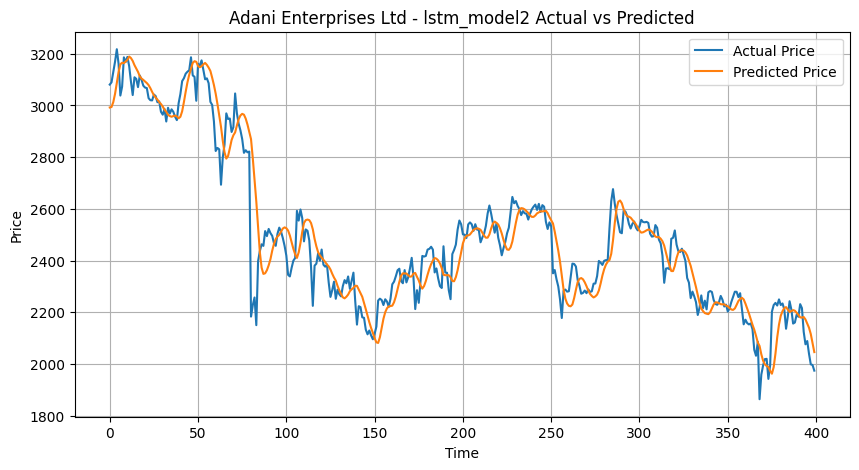

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Adani_Enterprises_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


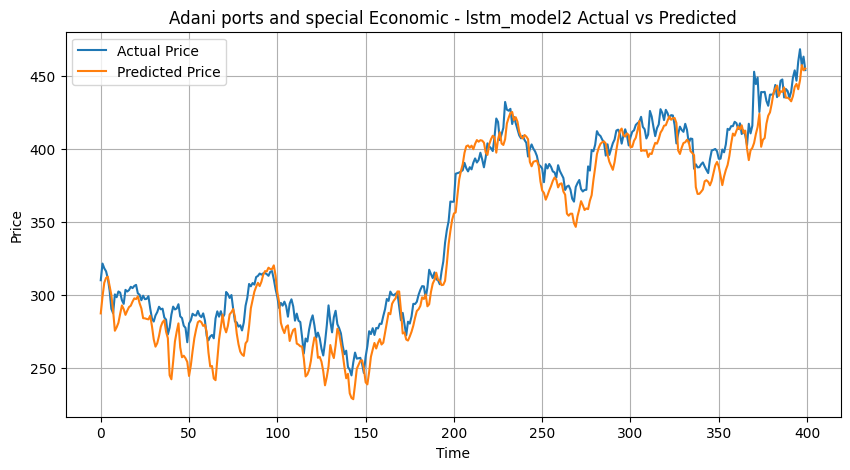

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Adani_ports_and_special_Economic_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


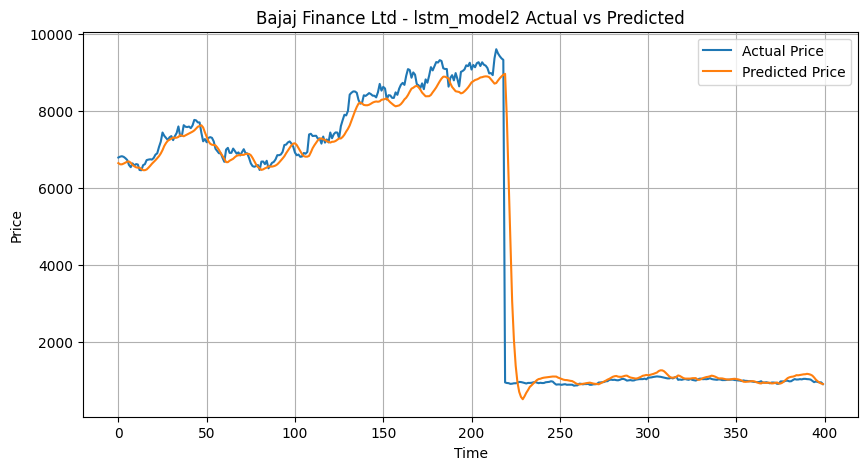

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Bajaj_Finance_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


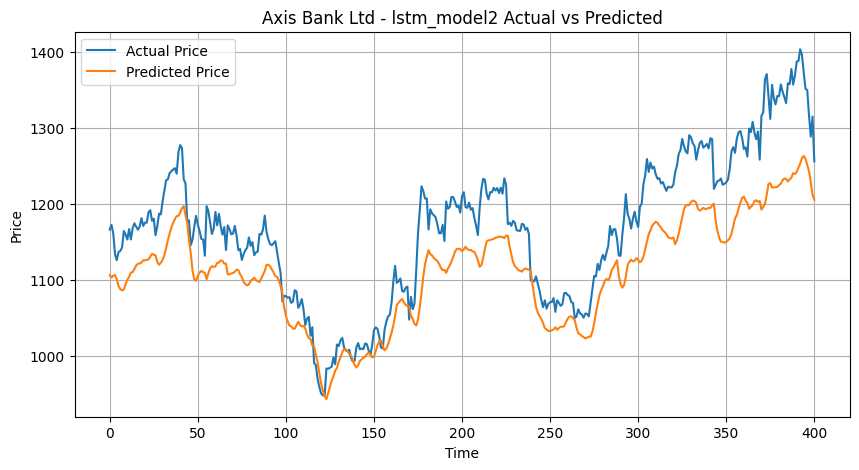

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Axis_Bank_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


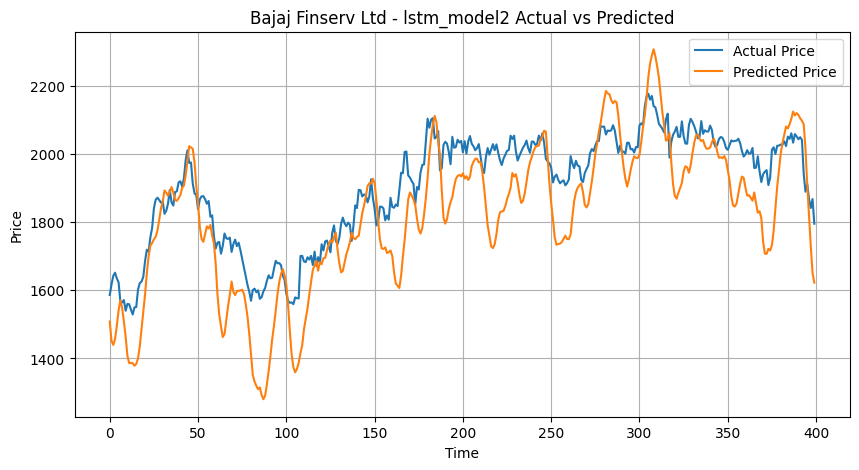

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Bajaj_Finserv_Ltd_lstm_model2_actual_vs_pred.png
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


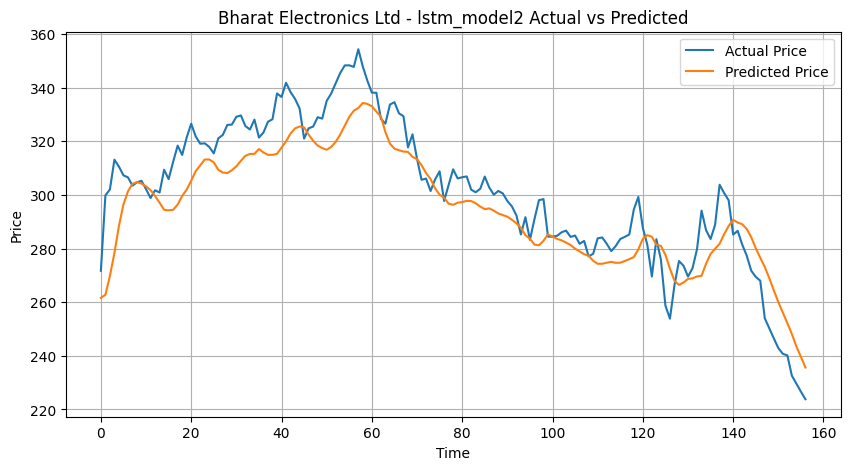

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Bharat_Electronics_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


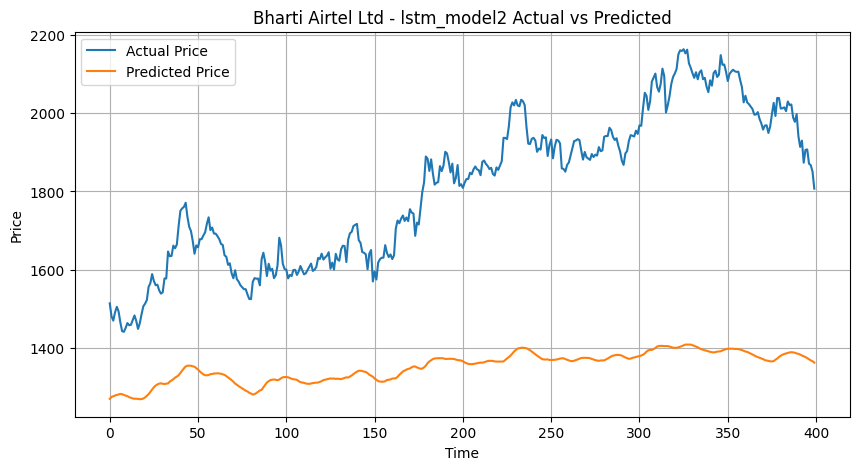

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Bharti_Airtel_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


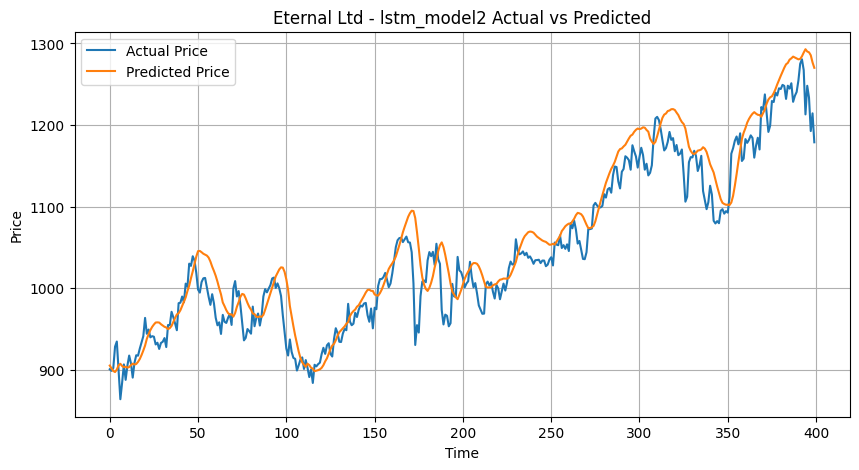

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Eternal_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


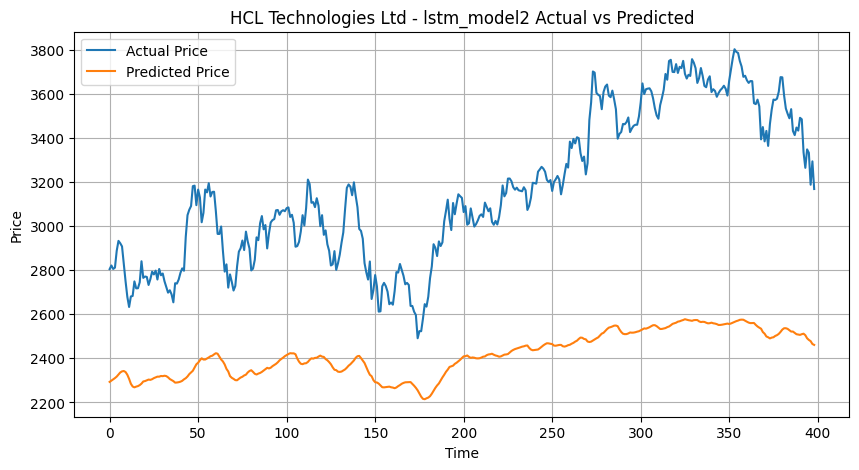

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/HCL_Technologies_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


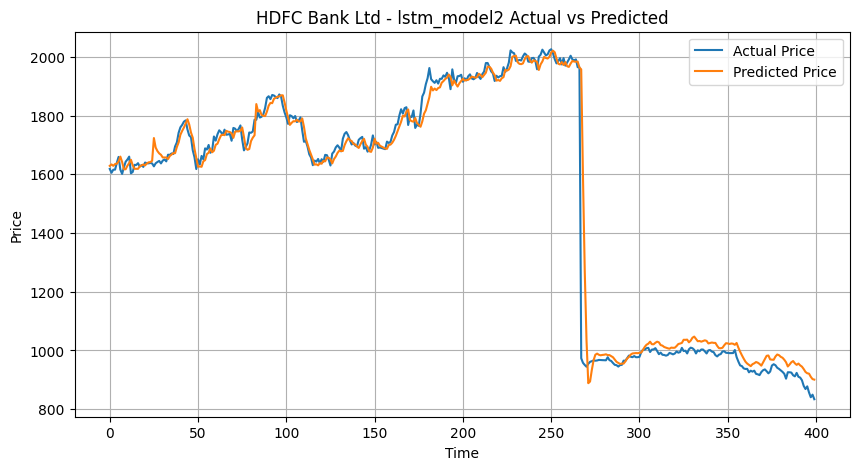

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/HDFC_Bank_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


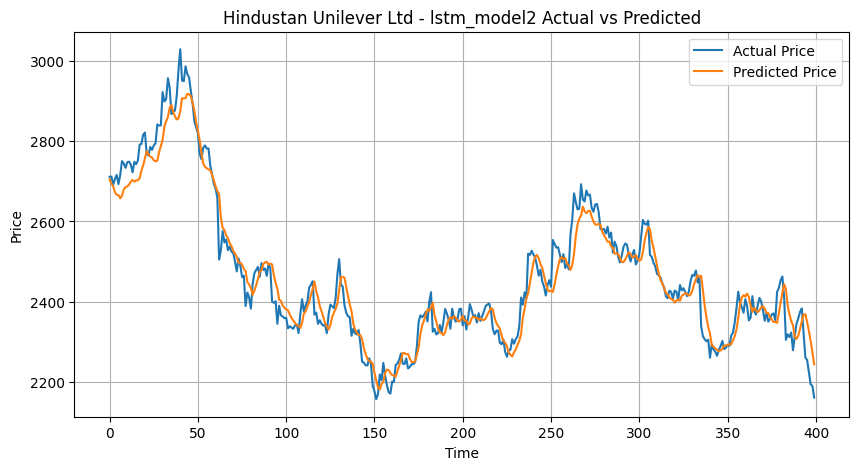

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Hindustan_Unilever_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


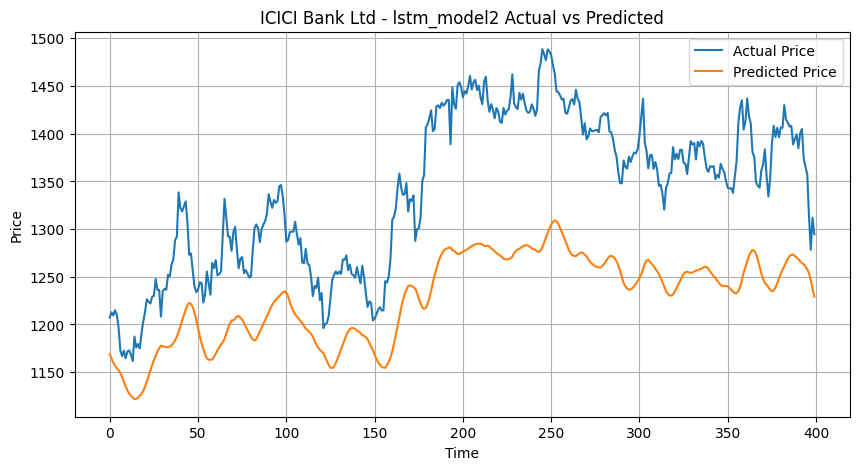

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/ICICI_Bank_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


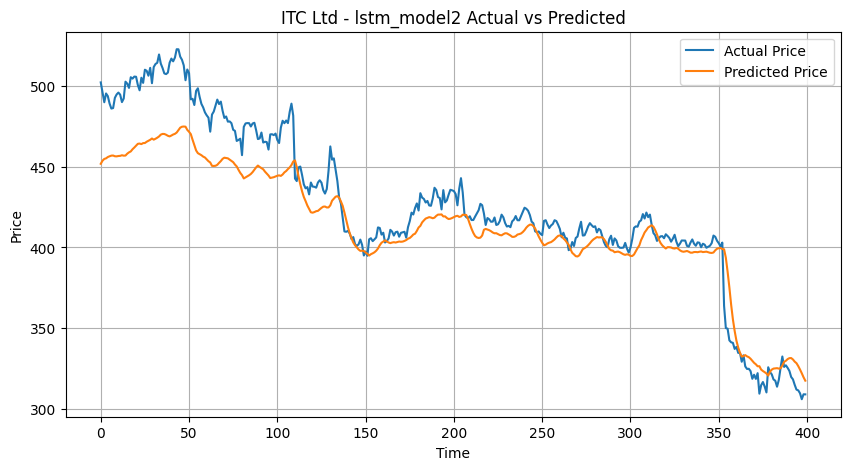

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/ITC_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


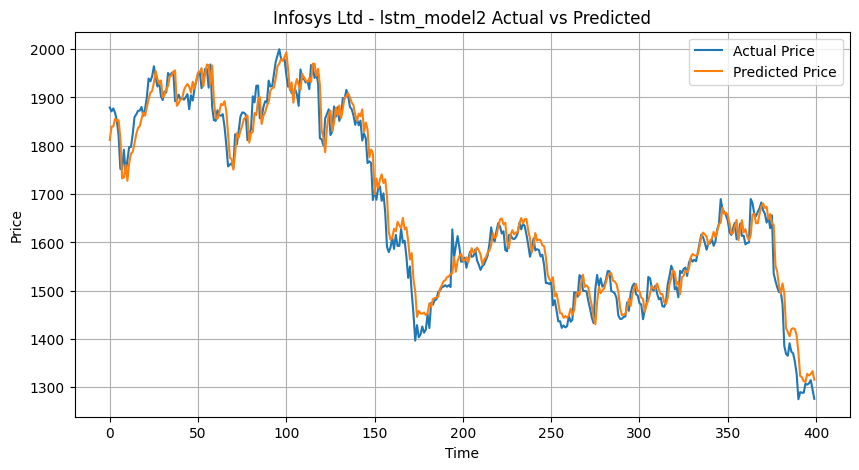

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Infosys_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


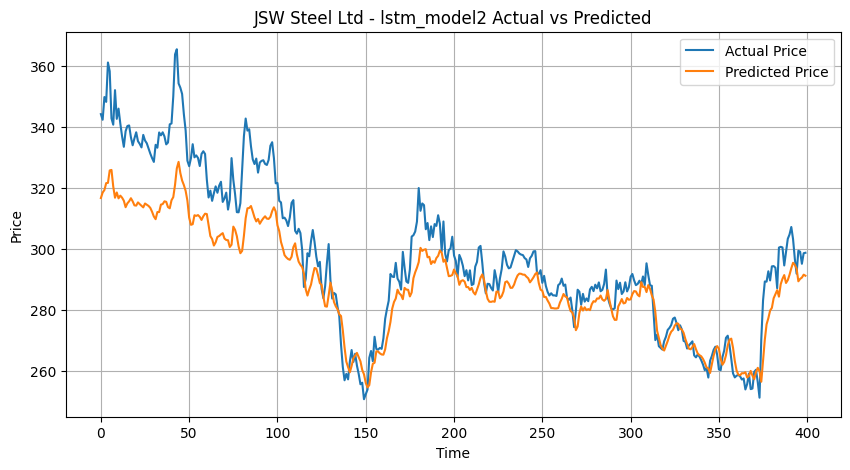

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/JSW_Steel_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


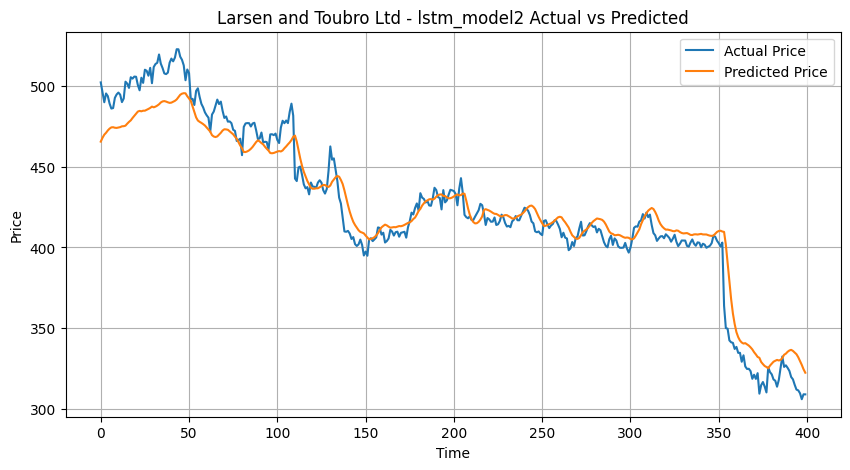

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Larsen_and_Toubro_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


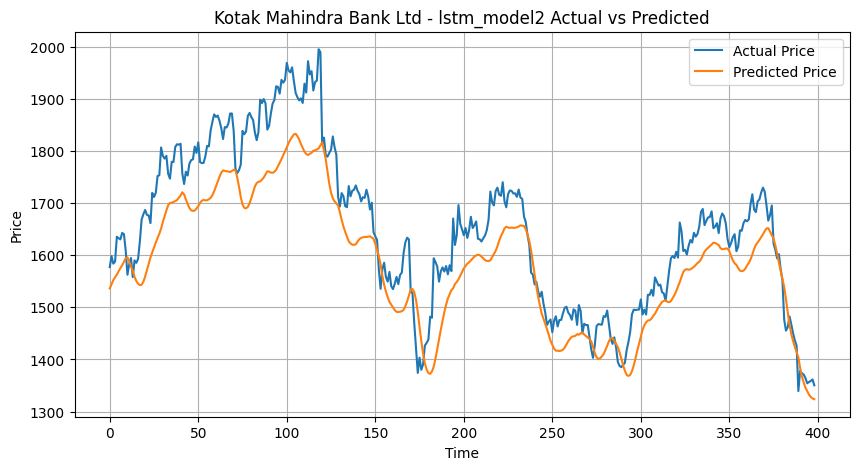

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Kotak_Mahindra_Bank_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


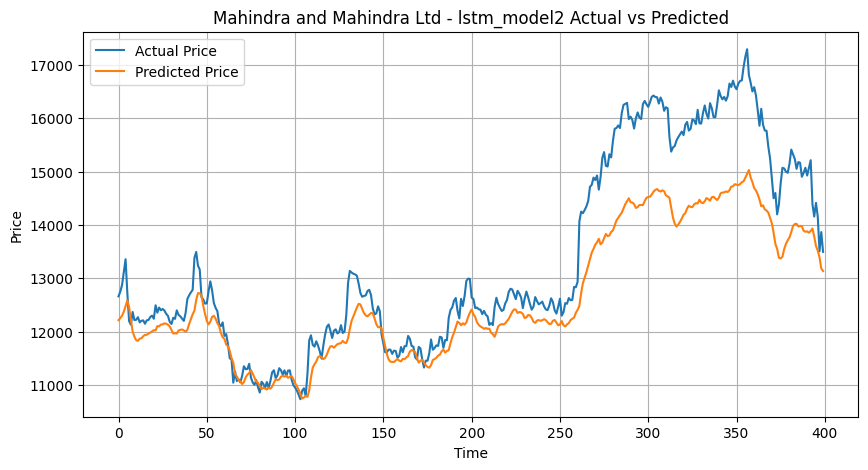

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Mahindra_and_Mahindra_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


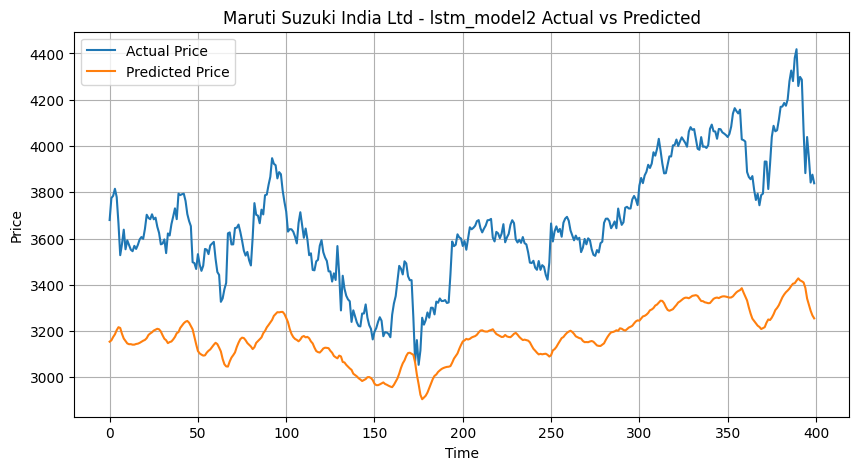

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Maruti_Suzuki_India_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


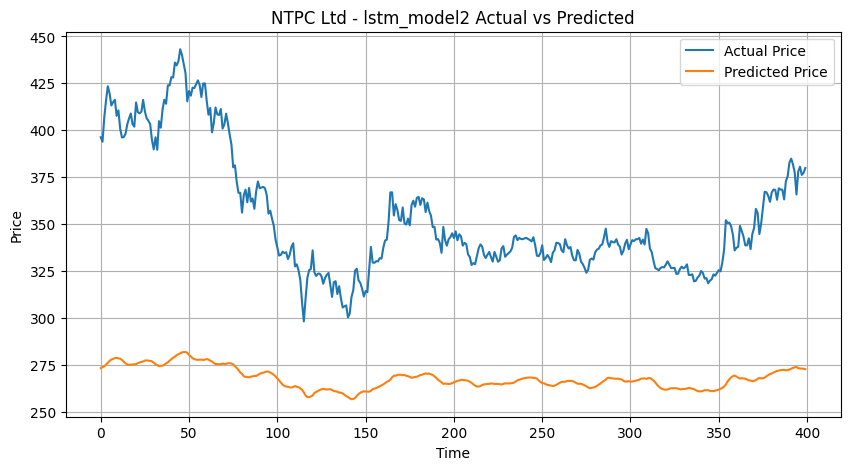

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/NTPC_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


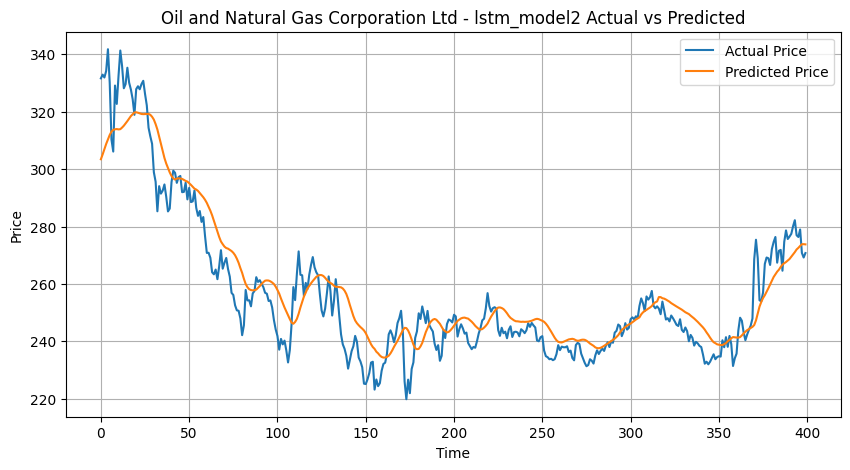

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Oil_and_Natural_Gas_Corporation_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


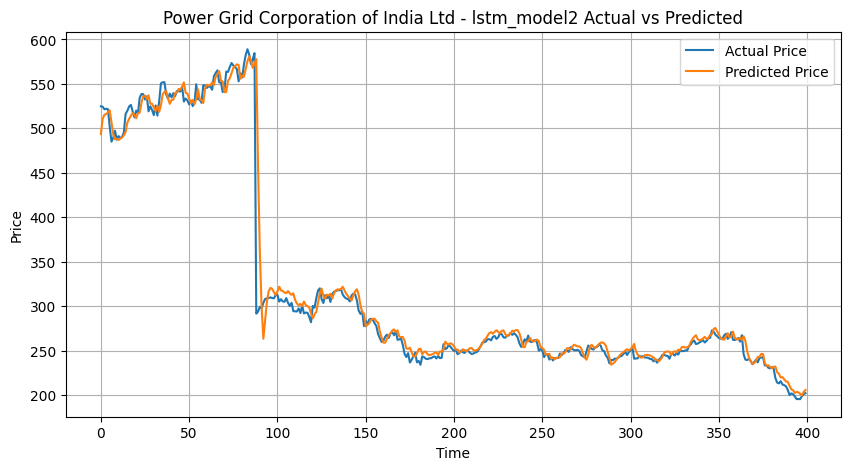

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Power_Grid_Corporation_of_India_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


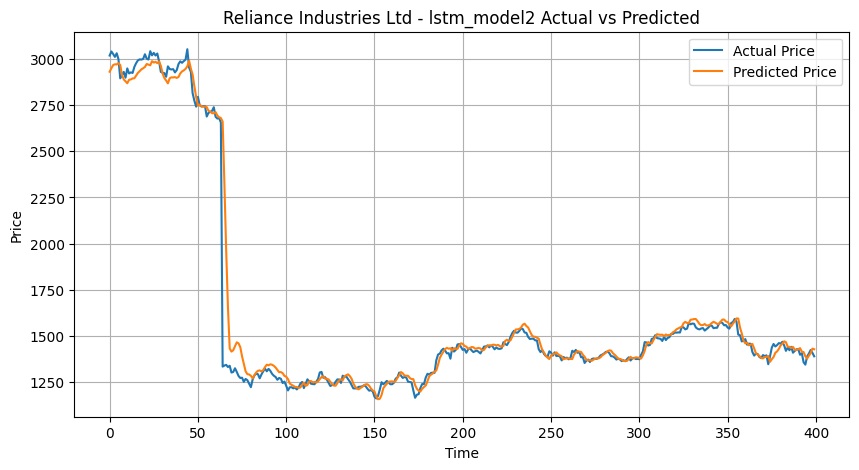

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Reliance_Industries_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


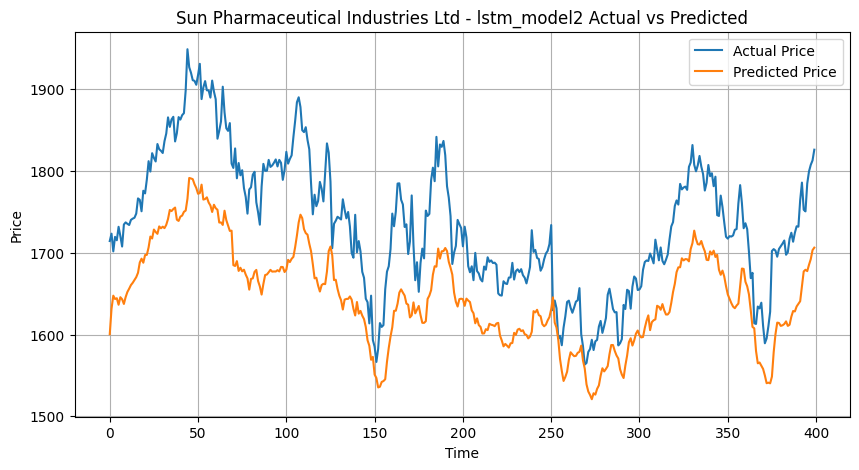

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Sun_Pharmaceutical_Industries_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


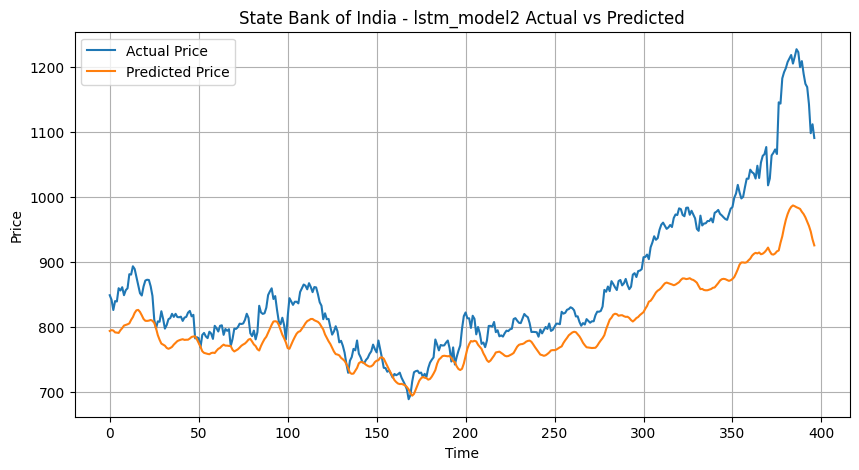

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/State_Bank_of_India_lstm_model2_actual_vs_pred.png
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


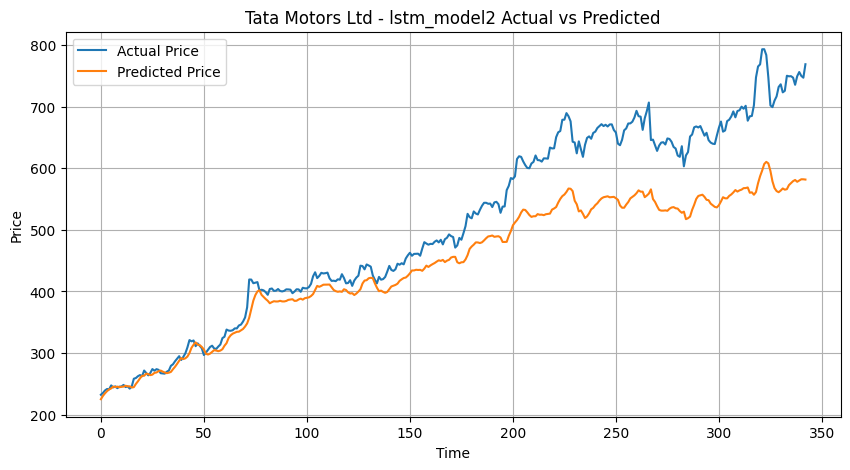

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Tata_Motors_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


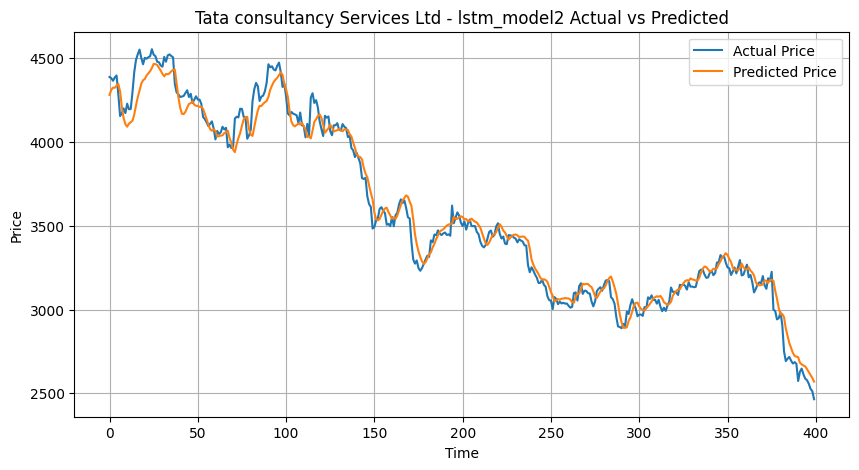

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Tata_consultancy_Services_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


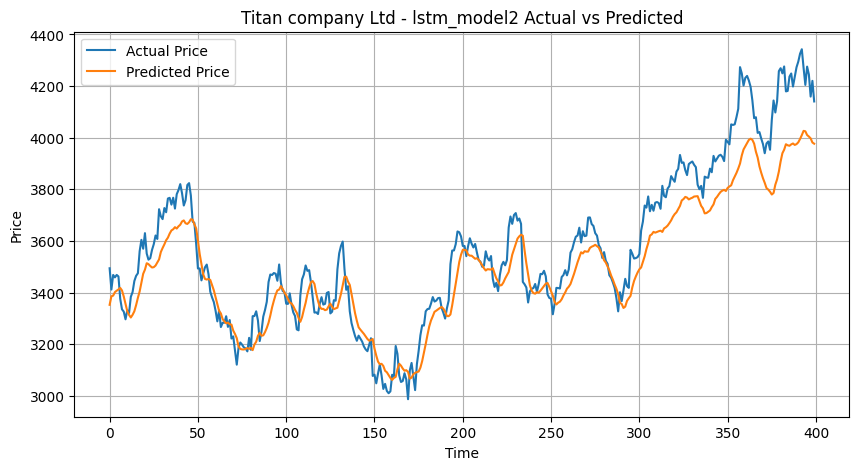

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Titan_company_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


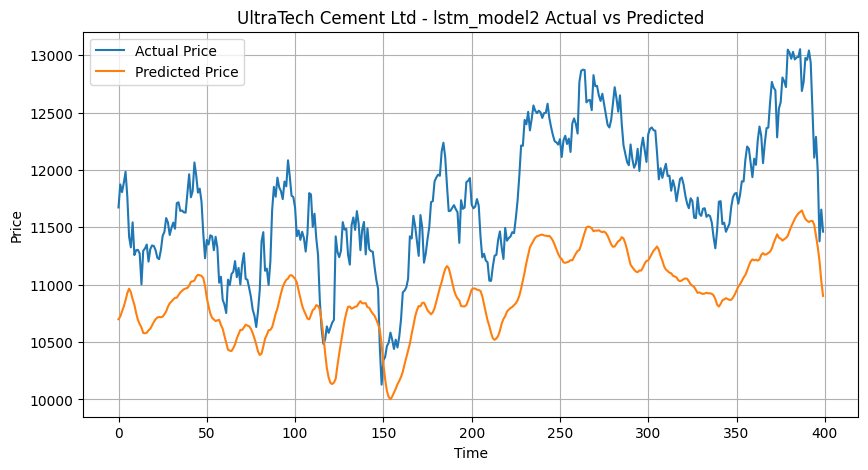

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/UltraTech_Cement_Ltd_lstm_model2_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


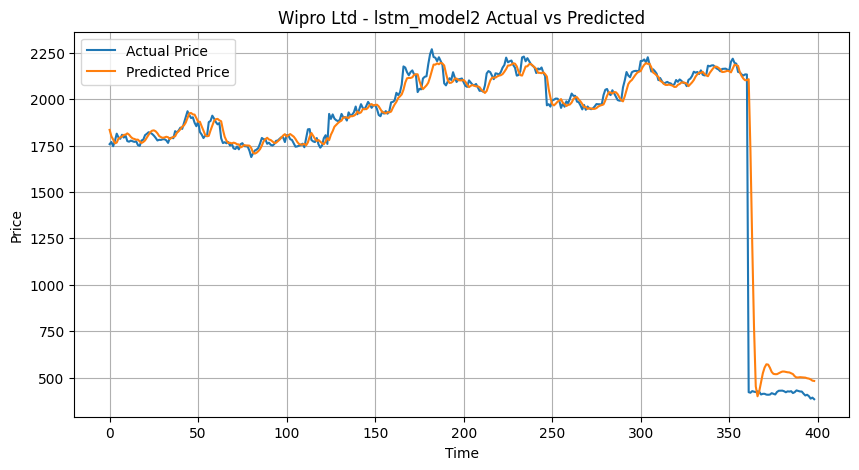

Plot saved at: /content/drive/MyDrive/major_data/LSTM_2/lstm2_plots/Wipro_Ltd_lstm_model2_actual_vs_pred.png


In [15]:

for company, data in all_lstm_models.items():

    model = data['model2']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # Predict
    y_pred = model.predict(X_test)

    # Inverse scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test_inv, label="Actual Price")
    plt.plot(y_pred_inv, label="Predicted Price")
    plt.title(f"{company} - {MODEL_TAG} Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

    # Save plot
    safe_name = company.replace(" ", "_").replace(".", "")
    plot_path = os.path.join(PLOT_DIR2, f"{safe_name}_{MODEL_TAG}_actual_vs_pred.png")
    plt.savefig(plot_path)
    plt.show()

    print(f"Plot saved at: {plot_path}")


In [16]:
# PREDICTION
from datetime import timedelta

def predict_future_lstm(company, all_lstm_models, processed_data, feature_columns, n_future=5):

    data = all_lstm_models[company]
    model = data['model2']
    feature_scaler = data['feature_scaler']
    target_scaler  = data['target_scaler']
    timesteps      = data['timesteps']

    df = processed_data[company].copy()

    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):
        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        next_row = current_seq[-1].copy()
        next_row[feature_columns.index('Close')] = pred_scaled
        current_seq = np.vstack([current_seq[1:], next_row])

    future_dates = [
        df['Date'].iloc[-1] + timedelta(days=i+1)
        for i in range(n_future)
    ]

    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')


In [17]:
all_lstm_predictions = {}

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm(
        company=company,
        all_lstm_models=all_lstm_models,
        processed_data=processed_data,
        feature_columns=feature_columns,
        n_future=5
    )

    all_lstm_predictions[company] = pred_df

    print(f" Future prediction done for {company}")


 Future prediction done for Adani Enterprises Ltd
 Future prediction done for Adani ports and special Economic
 Future prediction done for Bajaj Finance Ltd
 Future prediction done for Axis Bank Ltd
 Future prediction done for Bajaj Finserv Ltd
 Future prediction done for Bharat Electronics Ltd
 Future prediction done for Bharti Airtel Ltd
 Future prediction done for Eternal Ltd
 Future prediction done for HCL Technologies Ltd
 Future prediction done for HDFC Bank Ltd
 Future prediction done for Hindustan Unilever Ltd
 Future prediction done for ICICI Bank Ltd
 Future prediction done for ITC Ltd
 Future prediction done for Infosys Ltd
 Future prediction done for JSW Steel Ltd
 Future prediction done for Larsen and Toubro Ltd
 Future prediction done for Kotak Mahindra Bank Ltd
 Future prediction done for Mahindra and Mahindra Ltd
 Future prediction done for Maruti Suzuki India Ltd
 Future prediction done for NTPC Ltd
 Future prediction done for Oil and Natural Gas Corporation Ltd
 Futur

In [18]:
from datetime import timedelta
import numpy as np
import pandas as pd

n_future = 5
all_predictions_model2 = {}

close_index = feature_columns.index('Close')

for company, data in all_lstm_models.items():

    model = data['model2']   #  CHANGE HERE
    feature_scaler = data['feature_scaler']
    target_scaler = data['target_scaler']
    timesteps = data['timesteps']

    df = processed_data[company].copy()

    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):
        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        next_row = current_seq[-1].copy()
        next_row[close_index] = pred_scaled
        current_seq = np.vstack([current_seq[1:], next_row])

    last_date = df['Date'].iloc[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(n_future)]

    pred_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')

    all_predictions_model2[company] = pred_df   #  Separate dict

    print(f"{company} next {n_future} days predicted (Model2)")


Adani Enterprises Ltd next 5 days predicted (Model2)
Adani ports and special Economic next 5 days predicted (Model2)
Bajaj Finance Ltd next 5 days predicted (Model2)
Axis Bank Ltd next 5 days predicted (Model2)
Bajaj Finserv Ltd next 5 days predicted (Model2)
Bharat Electronics Ltd next 5 days predicted (Model2)
Bharti Airtel Ltd next 5 days predicted (Model2)
Eternal Ltd next 5 days predicted (Model2)
HCL Technologies Ltd next 5 days predicted (Model2)
HDFC Bank Ltd next 5 days predicted (Model2)
Hindustan Unilever Ltd next 5 days predicted (Model2)
ICICI Bank Ltd next 5 days predicted (Model2)
ITC Ltd next 5 days predicted (Model2)
Infosys Ltd next 5 days predicted (Model2)
JSW Steel Ltd next 5 days predicted (Model2)
Larsen and Toubro Ltd next 5 days predicted (Model2)
Kotak Mahindra Bank Ltd next 5 days predicted (Model2)
Mahindra and Mahindra Ltd next 5 days predicted (Model2)
Maruti Suzuki India Ltd next 5 days predicted (Model2)
NTPC Ltd next 5 days predicted (Model2)
Oil and Na

In [19]:
for company, pred in all_predictions_model2.items():
    print(company)
    print(pred)
    print("-" * 40)

Adani Enterprises Ltd
            Predicted_Close
Date                       
2026-03-12      2014.202947
2026-03-13      1987.764316
2026-03-14      1968.601564
2026-03-15      1954.141098
2026-03-16      1943.057148
----------------------------------------
Adani ports and special Economic
            Predicted_Close
Date                       
2026-03-12       450.934673
2026-03-13       446.543773
2026-03-14       444.195166
2026-03-15       443.811865
2026-03-16       444.765238
----------------------------------------
Bajaj Finance Ltd
            Predicted_Close
Date                       
2026-03-12       860.002581
2026-03-13       821.920023
2026-03-14       794.376513
2026-03-15       774.010837
2026-03-16       750.975788
----------------------------------------
Axis Bank Ltd
            Predicted_Close
Date                       
2026-03-12      1186.878587
2026-03-13      1168.935549
2026-03-14      1154.586327
2026-03-15      1144.027174
2026-03-16      1136.827867
------

In [21]:
import os
import shutil
import pandas as pd

# Convert dictionary of predictions to a single DataFrame
final_pred_df = pd.concat(all_predictions_model2, axis=1)
final_pred_df.columns = [col[0] for col in final_pred_df.columns]  # clean column labels
final_pred_df.index.name = 'Date'

# Main output file (MODEL 2)
output_path = "/content/drive/MyDrive/major_data/Future/LSTM_2/model2_future_predictions.csv"

# Ensure parent folder exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# If a directory accidentally exists with same name → remove it
if os.path.isdir(output_path):
    shutil.rmtree(output_path)

# Save combined predictions
final_pred_df.to_csv(output_path)

# Save individual company predictions
individual_folder = "/content/drive/MyDrive/major_data/Future/LSTM_2/model2_individual_predictions"
os.makedirs(individual_folder, exist_ok=True)

for company in final_pred_df.columns:
    company_safe = company.replace(" ", "_")

    company_df = final_pred_df[[company]]  # select single column
    company_df.to_csv(
        os.path.join(individual_folder, f"{company_safe}_future.csv")
    )

print(f"Combined file saved: {output_path}")
print(f"Individual company files saved in: {individual_folder}")

Combined file saved: /content/drive/MyDrive/major_data/Future/LSTM_2/model2_future_predictions.csv
Individual company files saved in: /content/drive/MyDrive/major_data/Future/LSTM_2/model2_individual_predictions


In [22]:
# RECOMMENDATION / RANKING
def expected_return(last_price, future_price):
    return ((future_price - last_price) / last_price) * 100

In [23]:
lstm2_ranking = []

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm(
        company,
        all_lstm_models,
        processed_data,
        feature_columns,
        n_future=5
    )

    last_close = processed_data[company]['Close'].iloc[-1]
    future_close = pred_df['Predicted_Close'].iloc[-1]

    ret = expected_return(last_close, future_close)

    lstm2_ranking.append({
        'Company': company,
        'Last_Close': round(last_close, 2),
        'Predicted_Close_5D': round(future_close, 2),
        'Expected_Return_%': round(ret, 2)
    })

# Create DataFrame
ranking_df_lstm2 = pd.DataFrame(lstm2_ranking)

# Sort by return
ranking_df_lstm2 = ranking_df_lstm2.sort_values(by='Expected_Return_%', ascending=False)

# Take TOP 10
top10_lstm2 = ranking_df_lstm2.head(10).reset_index(drop=True)

# Add Rank column
top10_lstm2.insert(0, 'Rank', range(1, len(top10_lstm2) + 1))

# Display
top10_lstm2

,Rank,Company,Last_Close,Predicted_Close_5D,Expected_Return_%
0,1,Wipro Ltd,383.20,483.44,26.16
1,2,Eternal Ltd,1178.80,1225.69,3.98
2,3,HDFC Bank Ltd,833.95,863.90,3.59
3,4,Larsen and Toubro Ltd,309.00,318.67,3.13
4,5,Power Grid Corporation of India Ltd,202.23,208.48,3.09
5,6,ITC Ltd,309.00,313.39,1.42
6,7,Oil and Natural Gas Corporation Ltd,270.75,272.94,0.81
7,8,Infosys Ltd,1276.30,1283.97,0.60
8,9,Tata consultancy Services Ltd,2464.90,2456.13,-0.36
9,10,Hindustan Unilever Ltd,2161.40,2152.68,-0.40


In [25]:
import os

# Path to existing folder
LSTM_RANKING_DIR = "/content/drive/MyDrive/major_data/Ranking"

# Create DataFrame (your code already did this)
ranking_df = pd.DataFrame(lstm2_ranking)
ranking_df = ranking_df.sort_values(
    by='Expected_Return_%',
    ascending=False
).reset_index(drop=True)

# Save file
file_path = os.path.join(LSTM_RANKING_DIR, "LSTM_2_top_ranking.csv")
ranking_df.to_csv(file_path, index=False)

print(f" Ranking saved successfully at:\n{file_path}")


 Ranking saved successfully at:
/content/drive/MyDrive/major_data/Ranking/LSTM_2_top_ranking.csv


In [26]:
import os
import pandas as pd

# Create folder for saving Model2 test results
PRED_RESULTS_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm2_predicted_prices"
os.makedirs(PRED_RESULTS_DIR2, exist_ok=True)

# Save predicted vs actual for each company (test set)
for company, data in all_lstm_models.items():
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = data['model2'].predict(X_test)   #  Model2
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    test_df = pd.DataFrame({
        'Actual_Close': y_true.flatten(),
        'Predicted_Close': y_pred.flatten()
    })

    file_path = os.path.join(PRED_RESULTS_DIR2, f"{company.replace(' ', '_')}_test_results.csv")
    test_df.to_csv(file_path, index=False)
    print(f" Test results saved for {company} (Model2)")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for Adani Enterprises Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
 Test results saved for Adani ports and special Economic (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
 Test results saved for Bajaj Finance Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
 Test results saved for Axis Bank Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
 Test results saved for Bajaj Finserv Ltd (Model2)
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
 Test results saved for Bharat Electronics Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
 Test results saved for Bharti Airtel Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
 Test results saved for Eternal Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for HCL Technologies Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for HDFC Bank Ltd (Model2)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for Hindustan Unilever 

In [27]:
import copy
lstm2_data_backup = copy.deepcopy(all_lstm_models)

In [28]:
MODEL_DIR2 = "/content/drive/MyDrive/major_data/LSTM_2/lstm_saved_model2"

lstm2_models = {}

for company_folder in os.listdir(MODEL_DIR2):

    company_path = os.path.join(MODEL_DIR2, company_folder)

    if os.path.isdir(company_path):

        company_name = company_folder.replace("_", " ")

        # Load model
        model = load_model(os.path.join(company_path, "lstm_model2.keras"))

        # Load scalers
        feature_scaler = joblib.load(
            os.path.join(company_path, "feature_scaler.pkl")
        )

        target_scaler = joblib.load(
            os.path.join(company_path, "target_scaler.pkl")
        )

        # Load metadata
        with open(os.path.join(company_path, "metadata.json"), "r") as f:
            metadata = json.load(f)

        lstm2_models[company_name] = {
            "model": model,
            "feature_scaler": feature_scaler,
            "target_scaler": target_scaler,
            "timesteps": metadata["timesteps"],
            "feature_columns": metadata["feature_columns"]
        }

        print(f" Loaded LSTM Model2 for {company_name}")

print("\n All LSTM Model2 loaded successfully!")

 Loaded LSTM Model2 for Adani Enterprises Ltd
 Loaded LSTM Model2 for Adani ports and special Economic
 Loaded LSTM Model2 for Bajaj Finance Ltd
 Loaded LSTM Model2 for Axis Bank Ltd
 Loaded LSTM Model2 for Bajaj Finserv Ltd
 Loaded LSTM Model2 for Bharat Electronics Ltd
 Loaded LSTM Model2 for Bharti Airtel Ltd
 Loaded LSTM Model2 for Eternal Ltd
 Loaded LSTM Model2 for HCL Technologies Ltd
 Loaded LSTM Model2 for HDFC Bank Ltd
 Loaded LSTM Model2 for Hindustan Unilever Ltd
 Loaded LSTM Model2 for ICICI Bank Ltd
 Loaded LSTM Model2 for ITC Ltd
 Loaded LSTM Model2 for Infosys Ltd
 Loaded LSTM Model2 for JSW Steel Ltd
 Loaded LSTM Model2 for Larsen and Toubro Ltd
 Loaded LSTM Model2 for Kotak Mahindra Bank Ltd
 Loaded LSTM Model2 for Mahindra and Mahindra Ltd
 Loaded LSTM Model2 for Maruti Suzuki India Ltd
 Loaded LSTM Model2 for NTPC Ltd
 Loaded LSTM Model2 for Oil and Natural Gas Corporation Ltd
 Loaded LSTM Model2 for Power Grid Corporation of India Ltd
 Loaded LSTM Model2 for Relian